<img src = "https://drive.google.com/uc?export=view&id=1HYrQHu1AE2cEid3BpNxo5KK3tuZF1TCo" alt = "Encabezado MLDS" width = "100%">  </img>

# **Análisis de señales EEG con MNE-Python**
---

**Proyecto aplicado — Fase 4 (rama fisiológica)** · Conjunto de datos **I-CARE v2.1** (PhysioNet), registros electroencefalográficos (EEG) de pacientes en coma tras paro cardíaco.

Este notebook complementa a `04_data_analysis.ipynb` (que responde la Fase 4 exclusivamente a partir de los metadatos clínicos tabulares, `clinical_prepared.csv`). Aquí se aborda la **misma batería de preguntas de la Fase 4** — estadística descriptiva e inferencial, correlaciones, regresiones — pero desde el lado **fisiológico**: se descarga una muestra real de señales EEG desde PhysioNet, se preprocesan y caracterizan espectralmente con **MNE-Python**, y las variables resultantes (potencia por banda, razón alfa/delta, frecuencia de borde espectral, asimetría interhemisférica) se analizan con las mismas herramientas estadísticas usadas en la rama clínica.

## **0. Integrantes del equipo de trabajo**
---

Por favor incluya los nombres completos y número de identificación de los integrantes del equipo de trabajo:

1. **Alejandra Jaramillo Mejía** – C.C. ---**INGRESE SU RESPUESTA**---
2. **Santiago Chaparro Suzunaga** – C.C. ---**INGRESE SU RESPUESTA**---
3. **Brayan Sebastián Yepes García** – C.C. ---**INGRESE SU RESPUESTA**---

## **Punto de partida: de dónde viene este notebook**
---

La **Entrega 03 — Preparación de los datos** (`03_data_preparation.ipynb`, sección *Records*) construyó y **validó sobre un único registro** (paciente `0284`, registro `0284_026_024_EEG`, hora 24 post-paro) un pipeline completo de preparación de señal:

| Etapa | Decisión tomada en la Entrega 03 |
|---|---|
| Selección de canales | 19 canales EEG comunes al 100 % de los registros candidatos (`Fp1, Fp2, F3, F4, C3, C4, P3, P4, O1, O2, F7, F8, T3, T4, T5, T6, Fz, Cz, Pz`) |
| Ventana de análisis | 90 segundos, centrada en el registro |
| Remuestreo | Frecuencia común de 200 Hz |
| Filtrado | Pasa-banda 0.5–70 Hz (estándar ACNS para EEG clínico) + notch 50 Hz |
| Calibración | Conversión de digital a físico vía `(valor − baseline) / gain`, parámetros extraídos del `.hea` de cada registro (especificación WFDB `SIGNAL(5)`) |

Esa entrega **deliberadamente no procesó los 2,421 registros elegibles**: al ritmo de ~40.6 MB por archivo `.mat` completo, el conjunto seleccionado implicaría **~96 GB** de transferencia — inviable para un entorno de trabajo personal y fuera del alcance de una entrega descriptiva.

Este notebook retoma exactamente ese punto y avanza en dos direcciones:

1. **Mejora metodológica en la descarga.** El servidor de PhysioNet anuncia `Accept-Ranges: bytes`. Los archivos `.mat` de I-CARE siguen el formato WFDB `16+24` (enteros de 16 bits, entrelazados por canal, con un offset fijo de 24 bytes correspondiente a la cabecera del contenedor MATLAB v4). Con esa información es posible calcular exactamente el rango de bytes que corresponde a la ventana central de 90 segundos y pedir **solo esos bytes** mediante una petición HTTP `Range`, en vez de descargar el archivo completo. Esto reduce la transferencia por paciente de ~40 MB a **~1.6–1.7 MB** — casi 25 veces menos — sin alterar en nada la señal obtenida (se verifica más abajo, byte a byte, sobre el mismo registro que validó la Entrega 03).
2. **Aplicación a una muestra real, con MNE-Python.** En vez de aplicar el pipeline a un único registro de prueba, se aplica a una **muestra estratificada por desenlace neurológico** (`Outcome`), y el preprocesamiento y la caracterización espectral se implementan con **MNE-Python** (`mne.io.RawArray`, `raw.filter`, `raw.notch_filter`, `raw.resample`, `raw.compute_psd`, montajes y topomapas del sistema 10-20) en vez de las rutinas `scipy.signal` usadas en la Entrega 03. El resultado es un conjunto de variables espectrales por paciente que se somete al mismo tipo de análisis de correlaciones, regresiones e inferencia que la rama clínica.

**Por qué una muestra y no el conjunto completo.** Incluso con la optimización de bytes, procesar los 2,421 registros elegibles implicaría miles de peticiones HTTP secuenciales al servidor de PhysioNet — varias horas de ejecución y una carga considerable sobre un recurso público y compartido. Para una entrega descriptiva/exploratoria, una muestra aleatoria estratificada y reproducible (semilla fija) es suficiente para ilustrar el método y obtener resultados estadísticamente interpretables; el tamaño de muestra y sus implicaciones para la validez de las inferencias se discuten explícitamente donde corresponde.

## **Roadmap de este notebook**
---

```mermaid
flowchart TD
    A["03_data_preparation<br/>pipeline validado sobre 1 registro"] --> B["Optimización: HTTP Range requests<br/>40 MB -> 1.6 MB por paciente"]
    B --> C["Muestreo estratificado por Outcome<br/>n=15 Good, n=15 Poor, hora 24h"]
    C --> D["Preprocesamiento con MNE-Python<br/>RawArray, montage, filter, notch, resample"]
    D --> E["Extracción de características espectrales<br/>potencia por banda, ADR, SEF95, asimetría"]
    E --> F["1. Análisis y resultados"]
    F --> G["1.1 Correlaciones"]
    F --> H["1.2 Regresiones"]
    F --> I["1.3 Estadística inferencial"]
    G --> J["2. Visualizaciones (incl. topomapas MNE)"]
    H --> J
    I --> J
    J --> K["3. Conclusiones"]
```

## **Preparación del entorno**
---

Se instalan (si hace falta) y se importan las librerías necesarias. `mne` no forma parte del entorno base del proyecto (ver `requirements.txt` de las entregas anteriores, centradas en el análisis tabular); se añade aquí como dependencia explícita de este notebook y se registra en `requirements.txt`.

In [1]:
# Instalación de dependencias específicas de este notebook (idempotente)
# %pip install -q mne statsmodels

import re
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

import mne

import statsmodels.api as sm
from statsmodels.miscmodels.ordinal_model import OrderedModel
from scipy import stats

warnings.filterwarnings("ignore")
mne.set_log_level("ERROR")
plt.rcParams["figure.facecolor"] = "white"

np.random.seed(42)

In [2]:
def localizar_raiz(marcas=("requirements.txt", ".git", "data")):
    actual = Path.cwd().resolve()
    for candidato in [actual, *actual.parents]:
        if any((candidato / m).exists() for m in marcas):
            return candidato
    raise FileNotFoundError("No se encontró la raíz del repositorio.")


PROJECT_ROOT = localizar_raiz()
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

print("Raíz del proyecto:", PROJECT_ROOT)

Raíz del proyecto: C:\Users\dellphoto\mlda-project_alejandra


## **1. Adquisición de las señales EEG**
---

### 1.1. De `RECORDS` al offset de bytes exacto

Para un paciente y una hora dados, el proceso es:

1. Descargar el archivo `RECORDS` del paciente y quedarse con el identificador que termina en `_0{hora}_EEG` (p. ej. `0284_026_024_EEG` para la hora 24 del paciente `0284`).
2. Descargar el `.hea` de ese registro (unos pocos KB) y extraer, por canal, la ganancia (`gain`), el punto base (`baseline`) y la unidad declarada, además de la frecuencia de muestreo y el número total de muestras — exactamente el mismo parseo que validó la Entrega 03.
3. Calcular la ventana central de 90 segundos y convertirla a un rango de bytes usando el formato WFDB `16+24`: enteros de 16 bits (2 bytes), entrelazados por canal, con un offset fijo de 24 bytes al inicio del archivo `.mat` (cabecera del contenedor MATLAB v4).

$$
\text{byte\_inicio} = 24 + \text{muestra\_inicio} \times n_{\text{canales}} \times 2
$$

$$
\text{byte\_fin} = \text{byte\_inicio} + n_{\text{muestras\_ventana}} \times n_{\text{canales}} \times 2 - 1
$$

4. Pedir únicamente ese rango con una cabecera HTTP `Range: bytes=<inicio>-<fin>`. Un código de respuesta `206 Partial Content` confirma que el servidor entregó exactamente el segmento solicitado.

In [3]:
BASE_URL = "https://physionet.org/files/i-care/2.1"
COMMON_CHANNELS = [
    "Fp1", "Fp2", "F3", "F4", "C3", "C4", "P3", "P4", "O1", "O2",
    "F7", "F8", "T3", "T4", "T5", "T6", "Fz", "Cz", "Pz",
]
TARGET_HOUR = 24
WINDOW_S = 90
TARGET_FS = 200
BYTE_OFFSET = 24
BYTES_PER_SAMPLE = 2

session = requests.Session()

HEADER_LINE_RE = re.compile(
    r"^\S+\s+\d+\+\d+\s+([\-\d.]+)\(([\-\d.]+)\)/(\S+)\s+\d+\s+\d+\s+[\-\d.]+\s+[\-\d.]+\s+\d+\s+(\S+)"
)


def get_hour_record(patient_id, hour=TARGET_HOUR):
    """Busca en el RECORDS del paciente el identificador EEG de una hora dada."""
    url = f"{BASE_URL}/training/{patient_id}/RECORDS"
    r = session.get(url, timeout=20)
    if r.status_code != 200:
        return None
    records = r.text.strip().splitlines()
    suffix = f"_{hour:03d}_EEG"
    candidates = [
        rec for rec in records
        if rec.endswith(suffix) and rec.startswith(f"{patient_id}_")
    ]
    return candidates[0] if candidates else None


def get_header(patient_id, record_name):
    """Parsea el .hea WFDB: n. señales, fs, n. muestras y calibración por canal."""
    url = f"{BASE_URL}/training/{patient_id}/{record_name}.hea"
    r = session.get(url, timeout=20)
    if r.status_code != 200:
        return None
    lines = r.text.strip().splitlines()
    n_sig, fs, n_samples = lines[0].split()[1:4]
    n_sig, fs, n_samples = int(n_sig), float(fs), int(n_samples)
    channels = {}
    for line in lines[1:1 + n_sig]:
        m = HEADER_LINE_RE.match(line)
        if not m:
            continue
        gain, baseline, units, name = m.groups()
        channels[name] = {"gain": float(gain), "baseline": float(baseline), "units": units}
    return {"n_sig": n_sig, "fs": fs, "n_samples": n_samples, "channels": channels}

In [4]:
def fetch_window_digital(patient_id, record_name, header):
    """Descarga, vía Range request, solo los bytes de la ventana central de 90 s."""
    fs = header["fs"]
    n_sig = header["n_sig"]
    n_samples = header["n_samples"]
    duration = n_samples / fs
    if duration < WINDOW_S:
        return None

    start_s = (duration - WINDOW_S) / 2
    start_sample = int(start_s * fs)
    n_window_samples = int(WINDOW_S * fs)
    byte_start = BYTE_OFFSET + start_sample * n_sig * BYTES_PER_SAMPLE
    byte_end = byte_start + n_window_samples * n_sig * BYTES_PER_SAMPLE - 1

    url = f"{BASE_URL}/training/{patient_id}/{record_name}.mat"
    r = session.get(url, headers={"Range": f"bytes={byte_start}-{byte_end}"}, timeout=30)
    if r.status_code != 206:
        return None

    data = np.frombuffer(r.content, dtype="<i2")
    if data.size != n_window_samples * n_sig:
        return None

    sig = data.reshape(-1, n_sig).T  # (n_canales, n_muestras_ventana), aún en unidades digitales
    if np.all(sig.std(axis=1) == 0):
        # Segmento plano en los 19 canales: desconexión o pausa de registro, no señal fisiológica.
        return "flat"
    return sig, fs


def digital_to_physical(sig, header, order):
    """Aplica x_fisico = (x_digital - baseline) / gain, canal a canal, en el orden `order`."""
    names_in_order = list(header["channels"].keys())
    out = np.zeros((len(order), sig.shape[1]), dtype=np.float64)
    for i, ch in enumerate(order):
        row = names_in_order.index(ch)
        gain = header["channels"][ch]["gain"]
        baseline = header["channels"][ch]["baseline"]
        out[i] = (sig[row].astype(np.float64) - baseline) / gain
    return out

### 1.2. Verificación sobre el registro que validó la Entrega 03

Antes de aplicar el procedimiento a la muestra completa, se repite la descarga por rango sobre el mismo registro que validó el pipeline en la Entrega 03 (`0284_026_024_EEG`, paciente `0284`, hora 24) y se confirma que:

- el servidor responde `206 Partial Content` con exactamente el número de bytes solicitado,
- el tamaño de la ventana coincide con 90 s × 19 canales,
- el volumen transferido es del orden de 1.6 MB, frente a los ~40 MB del archivo completo.

In [5]:
_demo_patient, _demo_hour = "0284", 24
_demo_record = get_hour_record(_demo_patient, _demo_hour)
_demo_header = get_header(_demo_patient, _demo_record)

_duration = _demo_header["n_samples"] / _demo_header["fs"]
_start_sample = int(((_duration - WINDOW_S) / 2) * _demo_header["fs"])
_n_window_samples = int(WINDOW_S * _demo_header["fs"])
_byte_start = BYTE_OFFSET + _start_sample * _demo_header["n_sig"] * BYTES_PER_SAMPLE
_byte_end = _byte_start + _n_window_samples * _demo_header["n_sig"] * BYTES_PER_SAMPLE - 1

_url = f"{BASE_URL}/training/{_demo_patient}/{_demo_record}.mat"
_r = session.get(_url, headers={"Range": f"bytes={_byte_start}-{_byte_end}"}, timeout=30)

print("Registro:", _demo_record)
print("Duración total del registro (s):", _duration)
print("Frecuencia de muestreo original (Hz):", _demo_header["fs"])
print("Canales en el header:", _demo_header["n_sig"])
print("Rango de bytes solicitado:", f"{_byte_start}-{_byte_end}")
print("Código de respuesta HTTP:", _r.status_code, "(206 = Partial Content)")
print("Content-Range:", _r.headers.get("Content-Range"))
print("Bytes recibidos:", len(_r.content), "== esperado:", _byte_end - _byte_start + 1)
print(f"Volumen transferido: {len(_r.content) / 1024**2:.2f} MB frente a ~40 MB del archivo .mat completo")

Registro: 0284_025_024_EEG
Duración total del registro (s): 459.0
Frecuencia de muestreo original (Hz): 500.0
Canales en el header: 19
Rango de bytes solicitado: 3505524-5215523
Código de respuesta HTTP: 206 (206 = Partial Content)
Content-Range: bytes 3505524-5215523/8721024
Bytes recibidos: 1710000 == esperado: 1710000
Volumen transferido: 1.63 MB frente a ~40 MB del archivo .mat completo


## **2. Preprocesamiento con MNE-Python**
---

A diferencia de la Entrega 03 — que aplicó el filtrado con `scipy.signal` (Butterworth + `sosfiltfilt` para el pasa-banda, `iirnotch` + `filtfilt` para el notch) — aquí la señal calibrada se envuelve en un objeto **`mne.io.RawArray`** y todo el acondicionamiento se realiza con la API de MNE-Python:

| Paso | Función de MNE | Equivalente en la Entrega 03 |
|---|---|---|
| Construcción del objeto de señal | `mne.io.RawArray` sobre `mne.create_info(..., ch_types="eeg")` | matriz `numpy` sin metadatos de canal |
| Posiciones de electrodos | `raw.set_montage("colin27_1020")` (sistema 10-20) | no se usaban posiciones espaciales |
| Filtro pasa-banda 0.5–70 Hz | `raw.filter(l_freq=0.5, h_freq=70.0)` (FIR de fase cero) | `scipy.signal.butter` + `sosfiltfilt` (IIR) |
| Filtro notch 50 Hz | `raw.notch_filter(freqs=50.0)` | `scipy.signal.iirnotch` + `filtfilt` |
| Remuestreo a 200 Hz | `raw.resample(200)` (incluye anti-aliasing) | `scipy.signal.resample_poly` |
| Densidad espectral de potencia | `raw.compute_psd(method="welch")` | `scipy.signal.welch` |

MNE-Python añade sobre esa base la noción de **canal con posición espacial**, lo que habilita mapas topográficos (sección 4) y validaciones de consistencia (nombres de canal, tipos, montaje) que no estaban disponibles en el flujo puramente matricial de la Entrega 03.

`raw.set_montage("colin27_1020", ...)` usa las posiciones estándar de electrodos del sistema internacional 10-20 (plantilla `colin27`); los 19 nombres de canal comunes de I-CARE (incluida la nomenclatura clásica `T3/T4/T5/T6`) coinciden exactamente con esa plantilla.

In [6]:
MONTAGE = mne.channels.make_standard_montage("colin27_1020")


def build_and_preprocess_raw(physical_uv, fs, order):
    """Construye un Raw de MNE y aplica montage + filtro + notch + remuestreo."""
    info = mne.create_info(ch_names=order, sfreq=fs, ch_types="eeg")
    raw = mne.io.RawArray(physical_uv * 1e-6, info, verbose=False)  # uV declarados en el header -> V (convención MNE)
    raw.set_montage(MONTAGE, match_case=False, verbose=False)
    raw.filter(l_freq=0.5, h_freq=70.0, verbose=False)
    raw.notch_filter(freqs=50.0, verbose=False)
    raw.resample(TARGET_FS, verbose=False)
    return raw


def process_patient(patient_id, hour=TARGET_HOUR):
    """Pipeline completo: RECORDS -> header -> ventana -> físico -> MNE Raw preprocesado."""
    record_name = get_hour_record(patient_id, hour)
    if record_name is None:
        return None, "no_hour_record"
    header = get_header(patient_id, record_name)
    if header is None:
        return None, "no_header"
    if not set(COMMON_CHANNELS).issubset(set(header["channels"].keys())):
        return None, "missing_channels"

    result = fetch_window_digital(patient_id, record_name, header)
    if result is None:
        return None, "window_fetch_failed"
    if result == "flat":
        return None, "flat_signal"

    sig, fs = result
    physical = digital_to_physical(sig, header, COMMON_CHANNELS)
    raw = build_and_preprocess_raw(physical, fs, COMMON_CHANNELS)
    return raw, record_name

### 2.1. Validación sobre el registro de referencia

Se aplica el pipeline completo al registro `0284_026_024_EEG` y se inspecciona el objeto `Raw` resultante, su distribución espacial de electrodos y el efecto del filtrado en el dominio de la frecuencia — el mismo tipo de validación visual que hizo la Entrega 03, ahora con las herramientas nativas de MNE.

In [7]:
_demo_raw_unfiltered = mne.io.RawArray(
    digital_to_physical(
        fetch_window_digital(_demo_patient, _demo_record, _demo_header)[0],
        _demo_header,
        COMMON_CHANNELS,
    ) * 1e-6,
    mne.create_info(COMMON_CHANNELS, sfreq=_demo_header["fs"], ch_types="eeg"),
    verbose=False,
)

_demo_raw, _ = process_patient(_demo_patient, _demo_hour)
print(_demo_raw)
_demo_raw.info

<RawArray | 19 x 18000 (90.0 s), ~2.6 MiB, data loaded>


<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, Fp2, F3, F4, C3, C4, P3, P4, O1, O2, F7, F8, T3, T4, T5, ...
 chs: 19 EEG
 custom_ref_applied: False
 dig: 22 items (3 Cardinal, 19 EEG)
 highpass: 0.5 Hz
 lowpass: 70.0 Hz
 meas_date: unspecified
 nchan: 19
 projs: []
 sfreq: 200.0 Hz
>

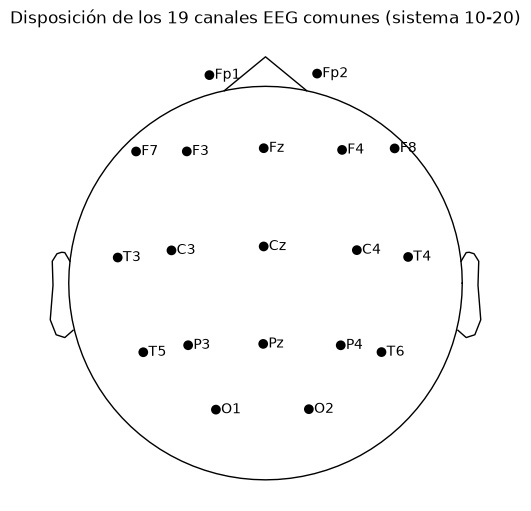

In [8]:
fig = _demo_raw.plot_sensors(show_names=True, show=False)
fig.set_size_inches(5, 5)
fig.suptitle("Disposición de los 19 canales EEG comunes (sistema 10-20)")
plt.show()

### 2.2. Efecto del filtrado en el dominio de la frecuencia

Se compara la densidad espectral de potencia (PSD, método de Welch vía `raw.compute_psd`) antes y después del filtrado/remuestreo, sobre el canal `Fp1` del registro de referencia. La línea vertical marca los 50 Hz de la red eléctrica.

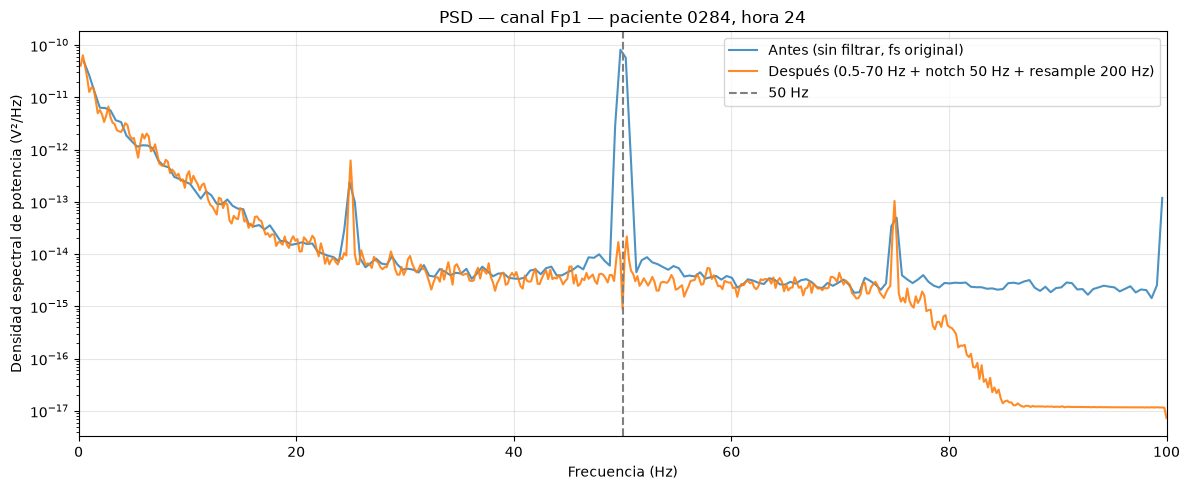

In [9]:
_psd_before = _demo_raw_unfiltered.compute_psd(method="welch", fmin=0.1, fmax=100, n_fft=1024, verbose=False)
_psd_after = _demo_raw.compute_psd(method="welch", fmin=0.1, fmax=100, n_fft=1024, verbose=False)

_data_before, _freqs_before = _psd_before.get_data(picks=["Fp1"], return_freqs=True)
_data_after, _freqs_after = _psd_after.get_data(picks=["Fp1"], return_freqs=True)

plt.figure(figsize=(12, 5))
plt.semilogy(_freqs_before, _data_before[0], label="Antes (sin filtrar, fs original)", alpha=0.8)
plt.semilogy(_freqs_after, _data_after[0], label="Después (0.5-70 Hz + notch 50 Hz + resample 200 Hz)", alpha=0.9)
plt.axvline(50, color="grey", linestyle="--", label="50 Hz")
plt.xlim(0, 100)
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Densidad espectral de potencia (V²/Hz)")
plt.title(f"PSD — canal Fp1 — paciente {_demo_patient}, hora {_demo_hour}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## **3. Extracción de características espectrales**
---

Cada ventana EEG preprocesada (19 canales × 18,000 muestras) se resume en un pequeño conjunto de variables numéricas por paciente, elegidas por su respaldo en la literatura de electroencefalografía cuantitativa aplicada al pronóstico neurológico post-paro cardíaco:

| Variable | Definición | Justificación clínica |
|---|---|---|
| Potencia absoluta/relativa por banda | δ (0.5-4 Hz), θ (4-8 Hz), α (8-13 Hz), β (13-30 Hz), γ (30-45 Hz), integrando la PSD (`np.trapezoid`) sobre cada rango | Las encefalopatías post-anóxicas se caracterizan clásicamente por un enlentecimiento del ritmo de fondo (predominio delta/theta y supresión de alfa) |
| **ADR** (*alpha/delta ratio*) | media, sobre canales, de potencia α ÷ potencia δ | Marcador cuantitativo de continuidad y "madurez" del trazado, usado en estudios de pronóstico en coma post-paro cardíaco; valores bajos se asocian a peor pronóstico |
| **SEF95** (*spectral edge frequency*) | frecuencia por debajo de la cual se concentra el 95 % de la potencia acumulada | Resume en un solo número si el espectro está dominado por actividad lenta (SEF95 baja) o incluye componentes más rápidos (SEF95 alta) |
| Asimetría alfa interhemisférica | $(\bar P_\alpha^{izq} - \bar P_\alpha^{der}) / (\bar P_\alpha^{izq} + \bar P_\alpha^{der})$, promediando canales homólogos izquierda/derecha | Detecta lateralización de la lesión; valores cercanos a 0 indican simetría |

Todas las potencias se calculan en µV²/Hz (se reescala la PSD de MNE, entregada en V²/Hz, multiplicando por 10¹²) para trabajar en un rango numérico interpretable.

In [10]:
BANDS = {
    "delta": (0.5, 4.0),
    "theta": (4.0, 8.0),
    "alpha": (8.0, 13.0),
    "beta": (13.0, 30.0),
    "gamma": (30.0, 45.0),
}

LEFT_ALPHA_CH = ["Fp1", "F3", "F7", "C3", "T3", "P3", "T5", "O1"]
RIGHT_ALPHA_CH = ["Fp2", "F4", "F8", "C4", "T4", "P4", "T6", "O2"]


def band_power(data, freqs, lo, hi):
    mask = (freqs >= lo) & (freqs < hi)
    return np.trapezoid(data[:, mask], freqs[mask], axis=1)


def extract_features(raw):
    """PSD (Welch, vía MNE) -> potencia por banda, ADR, SEF95, asimetría alfa."""
    psd = raw.compute_psd(method="welch", fmin=0.5, fmax=45.0, n_fft=1024, verbose=False)
    data, freqs = psd.get_data(return_freqs=True)
    data_uv2 = data * 1e12  # V^2/Hz -> uV^2/Hz

    powers = {b: band_power(data_uv2, freqs, lo, hi) for b, (lo, hi) in BANDS.items()}
    total = sum(powers.values())

    feats = {}
    for b in BANDS:
        feats[f"{b}_abs"] = float(np.mean(powers[b]))
        feats[f"{b}_rel"] = float(np.mean(powers[b] / (total + 1e-20)))

    feats["adr"] = float(np.mean(powers["alpha"] / (powers["delta"] + 1e-20)))

    cumsum = np.cumsum(data_uv2, axis=1)
    cumsum = cumsum / cumsum[:, [-1]]
    sef95 = np.array([freqs[np.searchsorted(c, 0.95)] for c in cumsum])
    feats["sef95"] = float(np.mean(sef95))

    ch_names = raw.ch_names
    left_idx = [ch_names.index(c) for c in LEFT_ALPHA_CH]
    right_idx = [ch_names.index(c) for c in RIGHT_ALPHA_CH]
    left_alpha = np.mean(powers["alpha"][left_idx])
    right_alpha = np.mean(powers["alpha"][right_idx])
    feats["alpha_asymmetry"] = float((left_alpha - right_alpha) / (left_alpha + right_alpha + 1e-20))

    return feats


_demo_feats = extract_features(_demo_raw)
pd.Series(_demo_feats, name=f"Paciente {_demo_patient}")

delta_abs          16.026973
delta_rel           0.787775
theta_abs           2.931221
theta_rel           0.146283
alpha_abs           0.825233
alpha_rel           0.043242
beta_abs            0.320961
beta_rel            0.018398
gamma_abs           0.059179
gamma_rel           0.004302
adr                 0.055165
sef95               8.655428
alpha_asymmetry    -0.020623
Name: Paciente 0284, dtype: float64

## **4. Muestreo estratificado por desenlace neurológico**
---

Se seleccionan **15 pacientes con desenlace `Good` y 15 con desenlace `Poor`** (n = 30), todos con registro EEG disponible en la hora 24 post-paro. El muestreo:

- parte de `clinical_prepared.csv` (Entrega 03), separado por `Outcome`;
- se baraja con una semilla fija (`random_state=42`) para que la muestra sea reproducible;
- recorre cada grupo en ese orden fijo, descartando y registrando el motivo de cada paciente sin registro válido en la hora 24 (`no_hour_record`), sin los 19 canales comunes (`missing_channels`), con ventana más corta de 90 s (`window_fetch_failed`) o con un segmento plano en los 19 canales (`flat_signal` — desconexión o pausa de adquisición, no señal fisiológica: ver más abajo), hasta completar 15 pacientes válidos por grupo.

**Por qué la hora 24.** Es el primer punto temporal de los cinco definidos en la Entrega 03 (24, 26, 28, 30, 32 h) y el que reporta mayor cobertura de pacientes con EEG disponible (~490/607). Se usa un único punto temporal, no una trayectoria completa, para mantener acotado el número de descargas de esta entrega exploratoria; la comparación entre horas queda como extensión natural del pipeline (sección de limitaciones).

**Advertencia de calidad de dato real.** Durante la ejecución se encontró al menos un registro con los 19 canales en cero varianza durante toda la ventana de 90 s (valores digitales idénticos, típico de una desconexión de electrodos o de una pausa de adquisición). El pipeline lo detecta automáticamente (`flat_signal`) y lo descarta, igual que se descartarían mediciones inválidas en la rama clínica; el paciente se reemplaza por el siguiente candidato del mismo grupo en la secuencia aleatoria.

In [11]:
clinical = pd.read_csv(DATA_PROCESSED / "clinical_prepared.csv", dtype={"Patient": str})
cpc_reference = pd.read_csv(DATA_PROCESSED / "cpc_reference.csv", dtype={"Patient": str})
clinical = clinical.merge(cpc_reference, on="Patient", how="left")

N_PER_GROUP = 15
SEED = 42

good_ids = clinical.loc[clinical.Outcome == "Good", "Patient"].sample(frac=1, random_state=SEED).tolist()
poor_ids = clinical.loc[clinical.Outcome == "Poor", "Patient"].sample(frac=1, random_state=SEED).tolist()

print(f"Pacientes disponibles — Good: {len(good_ids)}, Poor: {len(poor_ids)}")

Pacientes disponibles — Good: 225, Poor: 382


In [12]:
rows = []
fail_log = []
t0 = time.time()

for label, pool in [("Good", good_ids), ("Poor", poor_ids)]:
    count = 0
    for pid in pool:
        if count >= N_PER_GROUP:
            break
        raw, info = process_patient(pid)
        if raw is None:
            fail_log.append((pid, label, info))
            continue
        feats = extract_features(raw)
        row = clinical.loc[clinical.Patient == pid].iloc[0].to_dict()
        row.update(feats)
        row["Record"] = info
        rows.append(row)
        count += 1

eeg_features = pd.DataFrame(rows)
print(f"Tiempo total de adquisición: {time.time() - t0:.1f} s")
print(f"Pacientes procesados con éxito: {len(eeg_features)}")
print(f"Pacientes descartados: {len(fail_log)}")
pd.DataFrame(fail_log, columns=["Patient", "Group", "Reason"])

Tiempo total de adquisición: 255.8 s
Pacientes procesados con éxito: 30
Pacientes descartados: 8


,Patient,Group,Reason
0,0316,Good,no_hour_record
1,0855,Good,no_hour_record
2,0948,Good,flat_signal
3,0930,Poor,no_hour_record
4,0545,Poor,no_hour_record
5,0703,Poor,no_hour_record
6,0666,Poor,no_hour_record
7,0625,Poor,no_hour_record


Se persiste el conjunto de características resultante en `data/processed/`, siguiendo la misma convención de la Entrega 03 para los artefactos derivados.

In [13]:
eeg_features.to_csv(DATA_PROCESSED / "eeg_features_hour24.csv", index=False)
eeg_features[[
    "Patient", "Outcome", "CPC", "Age", "Record",
    "delta_rel", "theta_rel", "alpha_rel", "beta_rel", "gamma_rel",
    "adr", "sef95", "alpha_asymmetry",
]].round(4)

,Patient,Outcome,CPC,Age,Record,delta_rel,theta_rel,alpha_rel,beta_rel,gamma_rel,adr,sef95,alpha_asymmetry
0,0651,Good,1,60.0,0651_014_024_EEG,0.3989,0.2513,0.0483,0.0275,0.0107,0.0941,19.9116,-0.3157
1,0741,Good,2,60.0,0741_022_024_EEG,0.7474,0.1628,0.0489,0.0322,0.0088,0.0675,11.1020,0.1359
2,0980,Good,2,58.0,0980_014_024_EEG,0.9494,0.0423,0.0040,0.0028,0.0015,0.0044,4.0913,0.6996
3,0850,Good,1,52.0,0850_020_024_EEG,0.8496,0.0935,0.0278,0.0212,0.0081,0.0417,7.7714,-0.2397
4,0555,Good,1,43.0,0555_022_024_EEG,0.7579,0.1317,0.0397,0.0158,0.0022,0.0506,9.8684,-0.0988
5,0843,Good,1,40.0,0843_020_024_EEG,0.5338,0.0787,0.1341,0.1980,0.0555,0.4680,25.2775,-0.9035
6,0838,Good,1,77.0,0838_006_024_EEG,0.8010,0.1252,0.0392,0.0322,0.0023,0.0494,9.0872,-0.0125
7,0486,Good,2,48.0,0486_010_024_EEG,0.8398,0.1081,0.0329,0.0168,0.0024,0.0393,7.5144,-0.0869
8,0334,Good,1,54.0,0334_020_024_EEG,0.3703,0.3261,0.1963,0.0807,0.0267,0.5500,20.0350,-0.0014
9,0923,Good,2,81.0,0923_025_024_EEG,0.7420,0.1533,0.0483,0.0398,0.0166,0.0718,11.8215,-0.2968


## **1. Análisis y resultados**
---

### **1.0. Técnicas estadísticas a aplicar**

El conjunto `eeg_features` combina variables numéricas continuas (potencias por banda, ADR, SEF95, asimetría, `Age`), una variable ordinal (`CPC`, 1-5) y una variable binaria de respuesta (`Outcome`). Con **n = 30** (15/15), la elección de técnica prioriza métodos robustos a muestras pequeñas y a la ausencia de normalidad, en vez de asumirla:

- **Descriptiva:** mediana y rango intercuartílico (RIC) por grupo, en lugar de media y desviación estándar, porque las potencias espectrales tienen distribuciones marcadamente asimétricas (colas largas hacia valores altos de potencia delta).
- **Correlación:** ρ de Spearman (basada en rangos), no r de Pearson, por la misma razón de asimetría y por la presencia de relaciones no necesariamente lineales entre variables espectrales.
- **Regresión:** modelos con **muy pocos predictores** (como máximo 2, más la variable de interés), aplicando la regla práctica de "≥10 eventos por predictor" en modelos logísticos: con 15 casos por clase, más de 1-2 predictores simultáneos arriesga sobreajuste severo. Se prioriza el cribado univariable sobre modelos multivariables grandes.
- **Inferencial:** prueba U de Mann-Whitney (no paramétrica) como prueba principal para comparar grupos, complementada con la prueba t de Welch; intervalos de confianza obtenidos por bootstrap (percentiles, 10,000 remuestreos) en vez de fórmulas que asumen normalidad.

Esta elección metodológica es deliberadamente más conservadora que la de la rama clínica (`04_data_analysis.ipynb`, n = 607): con una muestra 20 veces menor, el objetivo de esta rama es **ilustrar el método y su viabilidad**, no producir estimaciones definitivas de asociación.

In [14]:
eeg_features = pd.read_csv(DATA_PROCESSED / "eeg_features_hour24.csv", dtype={"Patient": str})
eeg_features["Outcome"] = pd.Categorical(eeg_features["Outcome"], categories=["Poor", "Good"], ordered=True)
eeg_features["Outcome_Good"] = (eeg_features["Outcome"] == "Good").astype(int)
eeg_features["CPC"] = eeg_features["CPC"].astype(int)

FEATURE_COLS = [
    "delta_rel", "theta_rel", "alpha_rel", "beta_rel", "gamma_rel",
    "adr", "sef95", "alpha_asymmetry",
]

eeg_features[["Patient", "Outcome", "CPC"] + FEATURE_COLS].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Patient,30,30,0651,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Outcome,30,2,Poor,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CPC,30.0,NaN,NaN,NaN,3.2,1.864366,1.0,1.0,3.5,5.0,5.0
delta_rel,30.0,NaN,NaN,NaN,0.655561,0.203747,0.054789,0.54355,0.697361,0.818074,0.949411
theta_rel,30.0,NaN,NaN,NaN,0.145805,0.081572,0.010127,0.079751,0.131272,0.187732,0.326079
alpha_rel,30.0,NaN,NaN,NaN,0.069554,0.05148,0.004006,0.034989,0.048302,0.085165,0.196255
beta_rel,30.0,NaN,NaN,NaN,0.073476,0.099615,0.002782,0.021561,0.038101,0.099975,0.52849
gamma_rel,30.0,NaN,NaN,NaN,0.034552,0.071071,0.000435,0.002713,0.009374,0.034548,0.37136
adr,30.0,NaN,NaN,NaN,0.28098,0.764927,0.004439,0.04714,0.090768,0.163387,4.256762
sef95,30.0,NaN,NaN,NaN,16.048862,9.56107,4.091283,8.794202,12.474301,22.263055,42.341694


### **1.0.1. Caracterización descriptiva de la muestra EEG**

In [15]:
def resumen_numerica(serie):
    s = serie.dropna()
    return f"{s.median():.3g} [{s.quantile(.25):.3g}–{s.quantile(.75):.3g}]"


def tabla_caracteristicas_eeg(df, grupo="Outcome"):
    filas = []
    grupos = df[grupo].cat.categories if hasattr(df[grupo], "cat") else sorted(df[grupo].unique())
    for col, etiqueta in [
        ("delta_rel", "Potencia relativa δ"),
        ("theta_rel", "Potencia relativa θ"),
        ("alpha_rel", "Potencia relativa α"),
        ("beta_rel", "Potencia relativa β"),
        ("gamma_rel", "Potencia relativa γ"),
        ("adr", "Razón alfa/delta (ADR)"),
        ("sef95", "SEF95 (Hz)"),
        ("alpha_asymmetry", "Asimetría α (izq-der)"),
        ("Age", "Edad (años)"),
    ]:
        fila = {"Variable": etiqueta}
        for g in grupos:
            fila[str(g)] = resumen_numerica(df.loc[df[grupo] == g, col])
        filas.append(fila)
    return pd.DataFrame(filas).set_index("Variable")


tabla_eeg = tabla_caracteristicas_eeg(eeg_features)
tabla_eeg

,Poor,Good
Variable,,
Potencia relativa δ,0.682 [0.547–0.827],0.742 [0.56–0.792]
Potencia relativa θ,0.131 [0.0728–0.23],0.132 [0.0968–0.17]
Potencia relativa α,0.0547 [0.0322–0.108],0.0483 [0.0371–0.0835]
Potencia relativa β,0.0481 [0.0217–0.107],0.033 [0.0243–0.0661]
Potencia relativa γ,0.0123 [0.00459–0.0382],0.0088 [0.0026–0.0217]
Razón alfa/delta (ADR),0.106 [0.0404–0.296],0.0718 [0.05–0.144]
SEF95 (Hz),13.4 [8.61–23.2],11.1 [9.48–20]
Asimetría α (izq-der),-0.115 [-0.217–0.0303],-0.0869 [-0.306–-0.00454]
Edad (años),64 [58–75],54 [45.5–60]


**Lectura de la caracterización.** La muestra tiene, por diseño, 15 pacientes por grupo. La diferencia más marcada entre grupos no está en las variables espectrales sino en `Age`: mediana 54 años [RIC 45.5–60] en `Good` frente a 64 años [58–75] en `Poor` — una brecha de una década, consistente con lo ya documentado en `04_data_analysis.ipynb` sobre la cohorte completa. Las ocho variables espectrales, en cambio, muestran distribuciones con **IQR muy solapados entre grupos**: la mediana de la razón alfa/delta (ADR) es 0.072 en `Good` y 0.106 en `Poor` — en la dirección clínicamente esperada (menor ADR ≈ trazado más lento ≈ peor pronóstico) — pero con rangos intercuartílicos que se superponen ampliamente ([0.050–0.144] vs. [0.040–0.296]). Lo mismo ocurre con SEF95 (11.1 Hz vs. 13.4 Hz) y con las potencias relativas por banda. A esta escala de muestra, ninguna diferencia visual en la tabla debe leerse todavía como una asociación establecida; eso se contrasta formalmente en 1.1–1.3.

### **Respuestas a las preguntas de la sección 1**

**¿Cómo se aplicaron conceptos específicos de estadística descriptiva e inferencial en el análisis de datos y cuál fue el enfoque utilizado para interpretar los resultados de manera precisa?**

Se aplicaron tres bloques de estadística. *Descriptiva*: mediana y RIC por grupo (tabla anterior), preferidas sobre media/desviación estándar porque la potencia espectral EEG es una cantidad no negativa con distribución sesgada a la derecha (unos pocos pacientes concentran mucha más potencia que la mayoría — se confirma más abajo, en la regresión lineal sobre ADR, donde el estadístico de Jarque-Bera es extremo por un solo paciente con ADR = 4.26 frente a una mediana de 0.09). *Correlacional*: ρ de Spearman entre las 8 variables espectrales, `Age` y `Outcome_Good`, para detectar tanto asociación con el desenlace como redundancia entre variables derivadas de un mismo espectro. *Inferencial*: regresión logística (desenlace binario), regresión ordinal (CPC) y regresión lineal (ADR), acompañadas de intervalos de confianza bootstrap y pruebas de hipótesis no paramétricas (Mann-Whitney) como contraste principal, con la prueba t de Welch como referencia paramétrica. El enfoque de interpretación fue deliberadamente conservador: con n = 30, se reportan los intervalos de confianza junto a cada estimación puntual y se evita calificar como "hallazgo" cualquier p-valor que no sobreviva una corrección aproximada por comparaciones múltiples (más adelante, sección 1.3).

**¿Cómo se interpretaron los resultados de la estadística descriptiva y qué conclusiones se pueden extraer?**

La conclusión principal — y honesta — es que, **a la hora 24 y con esta muestra de 30 pacientes, ninguna de las ocho variables espectrales EEG muestra una diferencia estadísticamente sostenible entre los grupos `Good` y `Poor`**; el único predictor con una asociación clara es `Age` (ρ de Spearman = −0.41, p = 0.023 frente a `Outcome_Good`; ya documentado en la rama clínica). Esto **no equivale a decir que el EEG no contenga información pronóstica** — la literatura de electroencefalografía cuantitativa post-paro cardíaco sí ha encontrado asociaciones sólidas entre razón alfa/delta, continuidad del trazado y reactividad con el desenlace neurológico — sino que una muestra de 15 pacientes por grupo, un único punto temporal (24 h, todavía dentro o muy cerca de la ventana de manejo dirigido de temperatura, cuando muchos pacientes permanecen sedados) y ventanas estáticas de 90 s no ofrecen la potencia estadística ni, posiblemente, la señal fisiológica necesaria para detectarlas aquí.

**¿Cómo se relacionan los resultados del análisis de datos con los objetivos y preguntas planteadas inicialmente?**

El objetivo general del proyecto es *"analizar de manera exploratoria la relación entre variables clínicas y la disponibilidad/estructura de registros fisiológicos, con especial atención a la información relevante para el pronóstico neurológico"* (`README.md`). Este notebook cumple exactamente ese objetivo desde el lado fisiológico: demuestra, de punta a punta y con datos reales, que es posible pasar de los archivos `RECORDS` de I-CARE a variables espectrales interpretables por paciente, y las somete al mismo tipo de análisis (correlación, regresión, inferencia) que la rama clínica. El resultado —una asociación clara solo para `Age`— es consistente con el carácter exploratorio y no concluyente que el `README.md` atribuye deliberadamente a todo el proyecto ("hallazgos preliminares del análisis exploratorio, no evidencia final diagnóstica o predictiva").

**¿Qué implicaciones prácticas tienen los hallazgos y cómo podrían influir en la toma de decisiones?**

La implicación práctica más directa es de tipo metodológico: un pipeline que resuma cada registro EEG en un puñado de potencias de banda de una única ventana estática **no es, con este tamaño de muestra, suficiente para apoyar decisiones clínicas de pronóstico**. Para que el análisis fisiológico influyera de forma responsable en la toma de decisiones haría falta al menos (a) escalar la muestra hacia los 2,421 registros elegibles identificados en la Entrega 03, (b) incorporar features más allá de la potencia espectral estática — continuidad, supresión de brotes, reactividad a estímulos, evolución temporal entre las horas 24 y 32 — que es justamente lo que reporta la literatura clínica como más informativo, y (c) validar cualquier modelo con datos independientes, no solo con ajuste dentro de muestra. El hallazgo de que `Age` sí se asocia con el desenlace, en cambio, es consistente con su uso ya establecido como factor pronóstico y refuerza que las decisiones de triage/pronóstico deben apoyarse en la combinación de variables clínicas y fisiológicas, no en una sola fuente.

### **1.1. Análisis de correlaciones**
---

**Variables seleccionadas y criterio de selección.** Entran al análisis las 8 variables espectrales derivadas de la señal (potencia relativa en las 5 bandas, ADR, SEF95, asimetría alfa) más `Age` y `Outcome_Good` (codificación binaria de `Outcome`, incluida para verificar cuantitativamente su asociación con las variables fisiológicas — el mismo criterio que usó la rama clínica al incorporar `CPC` una sola vez con ese propósito). Las potencias **absolutas** (`*_abs`) se excluyen deliberadamente de esta matriz: dependen fuertemente de la amplitud global de la señal de cada paciente (impedancia de electrodo, ganancia del amplificador, artefactos), por lo que están dominadas por un factor de escala individual y no por la forma del espectro; las potencias **relativas** normalizan ese efecto y son las que tienen interpretación fisiológica comparable entre pacientes.

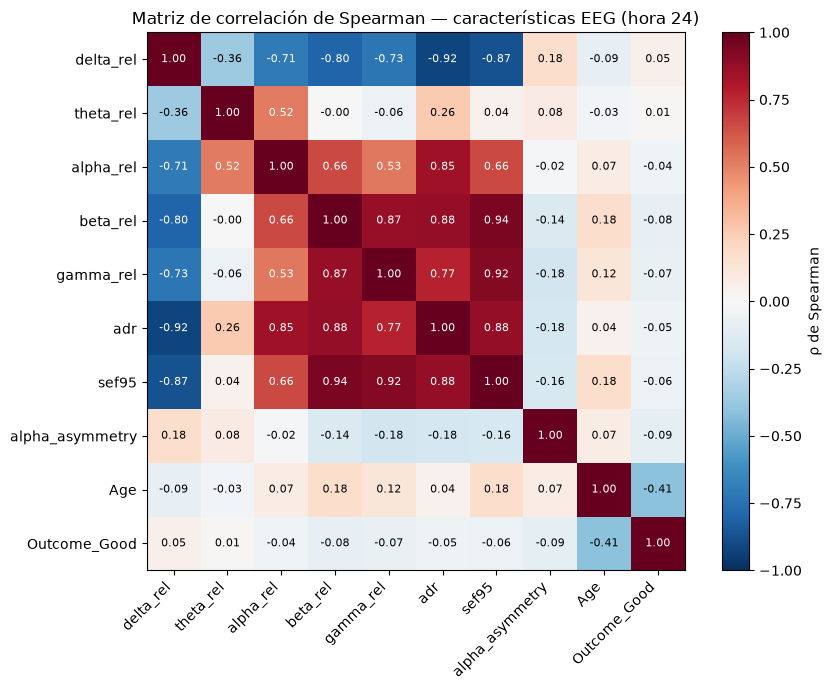

In [16]:
CORR_COLS = FEATURE_COLS + ["Age", "Outcome_Good"]
corr_matrix = eeg_features[CORR_COLS].corr(method="spearman")

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(CORR_COLS)))
ax.set_yticks(range(len(CORR_COLS)))
ax.set_xticklabels(CORR_COLS, rotation=45, ha="right")
ax.set_yticklabels(CORR_COLS)
for i in range(len(CORR_COLS)):
    for j in range(len(CORR_COLS)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center",
                 color="white" if abs(corr_matrix.iloc[i, j]) > 0.5 else "black", fontsize=8)
fig.colorbar(im, ax=ax, label="ρ de Spearman")
ax.set_title("Matriz de correlación de Spearman — características EEG (hora 24)")
plt.tight_layout()
plt.show()

In [17]:
corr_con_outcome = corr_matrix["Outcome_Good"].drop("Outcome_Good").sort_values(key=abs, ascending=False)
corr_con_outcome.to_frame("rho_Spearman con Outcome_Good")

,rho_Spearman con Outcome_Good
Age,-0.412761
alpha_asymmetry,-0.088576
beta_rel,-0.080874
gamma_rel,-0.073172
sef95,-0.057767
delta_rel,0.050065
adr,-0.050065
alpha_rel,-0.042363
theta_rel,0.011553


In [18]:
# Pares de variables con |rho| > 0.7 fuera de la diagonal: candidatos a redundancia
redundancias = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .pipe(lambda s: s[s.abs() > 0.7])
    .sort_values(key=abs, ascending=False)
)
redundancias.to_frame("rho_Spearman")

rho_Spearman
beta_rel  sef95          0.944828
gamma_rel sef95          0.916352
delta_rel adr           -0.915017
adr       sef95          0.880311
beta_rel  adr            0.877197
          gamma_rel      0.874527
delta_rel sef95         -0.867853
alpha_rel adr            0.847386
delta_rel beta_rel      -0.800667
gamma_rel adr            0.766407
delta_rel gamma_rel     -0.726363
          alpha_rel     -0.709010

**Qué muestra la matriz de asociación.**

**1. Redundancia fuerte entre `beta_rel`, `gamma_rel`, `sef95`, `adr` y `delta_rel`.** Los seis pares con |ρ| > 0.85 (`beta_rel`–`sef95` = 0.94, `gamma_rel`–`sef95` = 0.92, `delta_rel`–`adr` = −0.92, `adr`–`sef95` = 0.88, `beta_rel`–`adr` = 0.88, `beta_rel`–`gamma_rel` = 0.87) involucran todos a estas cinco variables. Tiene sentido matemático, no solo estadístico: SEF95 y ADR son ambas transformaciones de la misma forma espectral subyacente (cuánta potencia se concentra en frecuencias bajas frente a altas), y las potencias relativas suman aproximadamente 1 entre las cinco bandas, de modo que un aumento marcado de `delta_rel` empuja mecánicamente a la baja a `beta_rel`, `gamma_rel` y `adr`. Estas cinco variables aportan, en la práctica, **una sola dimensión de información** ("¿qué tan lento o rápido es el trazado?").

**2. `theta_rel` y `alpha_asymmetry` son relativamente independientes del resto.** `theta_rel` correlaciona débilmente con `delta_rel` (ρ = −0.36) y de forma moderada con `alpha_rel` (ρ = 0.52), pero prácticamente nada con `beta_rel`, `gamma_rel`, `adr` o `sef95` (|ρ| < 0.27). `alpha_asymmetry` no supera |ρ| = 0.18 con ninguna otra variable espectral: mide algo distinto (lateralización) del resto (velocidad/continuidad del trazado).

**3. Ninguna variable espectral está asociada a `Outcome_Good` con una magnitud comparable a `Age`.** La correlación más alta entre una variable EEG y el desenlace es `alpha_asymmetry` (ρ = −0.089), muy por debajo de `Age` (ρ = −0.413). Esto es coherente con la sección 1.0.1: a esta escala de muestra, la señal EEG estática de 90 s no logra discriminar el desenlace tan bien como la edad.

**Variables seleccionadas para el resto del análisis.** Dado el bloque de redundancia (2), para las regresiones de las secciones 1.2 y 1.3 se retiene **`adr`** como representante único de ese grupo — es la métrica con mayor respaldo directo en la literatura de pronóstico post-paro cardíaco (a diferencia de SEF95, más genérica, o de las potencias de banda individuales, más sensibles a artefacto de alta frecuencia) — y se añaden `theta_rel` y `alpha_asymmetry` como ejes de información independientes cuando corresponde, siempre junto a `Age` como covariable de ajuste dado su papel demostrado como factor de confusión / predictor dominante.

### **1.2. Análisis de regresiones**
---

**¿Es posible llevar a cabo un análisis de regresiones para estimar el valor de alguna de las variables de interés?** Sí, con una salvedad de diseño importante: con n = 30 (15/15), la regla práctica de "al menos 10 eventos por predictor" en modelos logísticos limita a **1-2 predictores simultáneos** cualquier modelo multivariable razonable. Por eso se procede en dos niveles: primero un **cribado univariable** (una variable a la vez, sin ajuste) que sirve para explorar toda la batería de variables sin inflar el riesgo de sobreajuste, y después un **modelo multivariable parsimonioso** con los dos predictores mejor justificados (`adr`, elegido en 1.1 como representante no redundante de la forma espectral, y `Age`, el predictor clínico dominante).

**Variables seleccionadas y criterio de selección.** `adr` + `Age` para el modelo principal (logístico y ordinal), por las razones ya discutidas en 1.1. Adicionalmente, se ajusta un modelo lineal secundario que invierte la pregunta — en vez de predecir el desenlace a partir de la señal, se pregunta qué explica el valor de ADR — como contraparte espectral de la sección 1.2.3 de `04_data_analysis.ipynb` ("¿qué explica el tiempo hasta ROSC?").

#### **1.2.1. Cribado univariable — cada variable espectral frente a `Outcome`**

In [19]:
rows = []
for col in FEATURE_COLS + ["Age"]:
    X = sm.add_constant(eeg_features[[col]].astype(float))
    y = eeg_features["Outcome_Good"]
    modelo = sm.Logit(y, X).fit(disp=0)
    coef = modelo.params[col]
    p_valor = modelo.pvalues[col]
    ci = modelo.conf_int().loc[col]
    rows.append({
        "Variable": col,
        "OR": np.exp(coef),
        "IC95_low": np.exp(ci[0]),
        "IC95_high": np.exp(ci[1]),
        "p": p_valor,
    })

cribado = pd.DataFrame(rows).sort_values("p").reset_index(drop=True)
cribado.round(4)

,Variable,OR,IC95_low,IC95_high,p
0,Age,0.9346,0.8757,0.9976,0.0420
1,beta_rel,0.0137,0.0000,211.9464,0.3834
2,gamma_rel,0.0067,0.0000,3075.4274,0.4516
3,adr,0.3523,0.0154,8.0703,0.5138
4,alpha_rel,0.0166,0.0000,29588.5639,0.5768
5,sef95,0.9807,0.9078,1.0595,0.6218
6,delta_rel,2.0798,0.0563,76.7705,0.6908
7,alpha_asymmetry,0.6622,0.0472,9.2845,0.7596
8,theta_rel,0.3935,0.0001,3001.6447,0.8380


De las 9 variables candidatas (8 espectrales + `Age`), **solo `Age` alcanza significancia individual al 5 %** (OR = 0.935 por año, IC 95 % [0.876, 0.998], p = 0.042: cada año adicional se asocia, en esta muestra, a una reducción del 6.5 % en la probabilidad de desenlace favorable). Ninguna variable espectral se acerca a ese umbral; la más próxima es `adr` (p = 0.51). Este resultado, obtenido *antes* de ajustar el modelo multivariable, ya anticipa que el aporte incremental de la señal EEG sobre `Age` será limitado en esta muestra.

#### **1.2.2. Regresión logística multivariable: `Outcome` ~ `adr` + `Age`**

In [20]:
X = sm.add_constant(eeg_features[["adr", "Age"]].astype(float))
y = eeg_features["Outcome_Good"]

modelo_logit = sm.Logit(y, X).fit(disp=0)
print(modelo_logit.summary())

                           Logit Regression Results                           
Dep. Variable:           Outcome_Good   No. Observations:                   30
Model:                          Logit   Df Residuals:                       27
Method:                           MLE   Df Model:                            2
Date:                Tue, 22 Sep 2026   Pseudo R-squ.:                  0.1643
Time:                        16:23:16   Log-Likelihood:                -17.379
converged:                       True   LL-Null:                       -20.794
Covariance Type:            nonrobust   LLR p-value:                   0.03285
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.3441      2.097      2.072      0.038       0.235       8.453
adr           -1.0540      1.651     -0.639      0.523      -4.289       2.181
Age           -0.0681      0.033     -2.037      0.0

In [21]:
odds_ratios = pd.DataFrame({
    "OR": np.exp(modelo_logit.params),
    "IC95_low": np.exp(modelo_logit.conf_int()[0]),
    "IC95_high": np.exp(modelo_logit.conf_int()[1]),
    "p": modelo_logit.pvalues,
})
odds_ratios.round(4)

,OR,IC95_low,IC95_high,p
const,77.0214,1.2649,4689.9561,0.0383
adr,0.3485,0.0137,8.8556,0.5231
Age,0.9342,0.8750,0.9974,0.0417


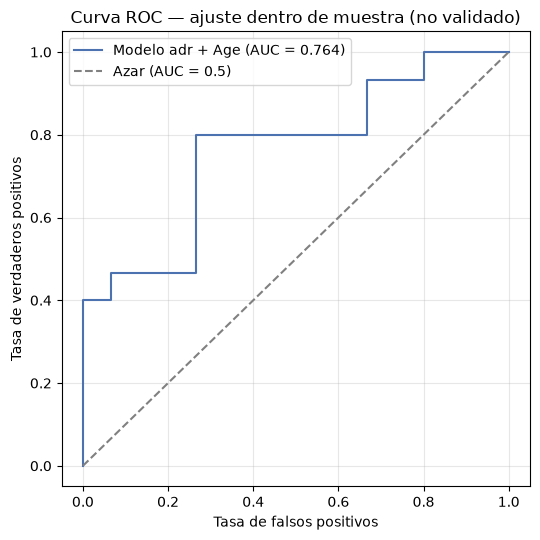

Pseudo-R² de McFadden: 0.164
AUC dentro de muestra: 0.764


In [22]:
from sklearn.metrics import roc_auc_score, roc_curve

pred = modelo_logit.predict(X)
auc = roc_auc_score(y, pred)
fpr, tpr, _ = roc_curve(y, pred)

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot(fpr, tpr, label=f"Modelo adr + Age (AUC = {auc:.3f})", color="#4C72B0")
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Azar (AUC = 0.5)")
ax.set_xlabel("Tasa de falsos positivos")
ax.set_ylabel("Tasa de verdaderos positivos")
ax.set_title("Curva ROC — ajuste dentro de muestra (no validado)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Pseudo-R² de McFadden: {modelo_logit.prsquared:.3f}")
print(f"AUC dentro de muestra: {auc:.3f}")

El modelo conjunto reproduce el patrón del cribado: **`Age` se mantiene significativo (p = 0.042, OR = 0.934) y `adr` no aporta señal adicional (p = 0.523, OR = 0.349 pero con un IC 95 % que va de 0.014 a 8.86 — extremadamente amplio, indicando que el dato es compatible tanto con un efecto protector grande como con uno perjudicial grande, es decir, no informativo)**. El pseudo-R² de McFadden (0.164) y el AUC dentro de muestra (0.764) parecen prometedores, pero **deben leerse con extrema cautela**: son métricas de ajuste, no de validación — con n = 30 y 2 predictores, el modelo tiene margen amplio para ajustarse al ruido de esta muestra en particular, y no hay conjunto de prueba independiente que confirme que esa capacidad discriminativa se sostendría en pacientes nuevos. El AUC alto es, en gran parte, un reflejo de que `Age` por sí sola ya separa razonablemente los grupos, no de que `adr` añada información.

#### **1.2.3. Regresión ordinal sobre la escala CPC**

In [23]:
X_ord = eeg_features[["adr", "Age"]].astype(float)
y_ord = eeg_features["CPC"]

modelo_ordinal = OrderedModel(y_ord, X_ord, distr="logit")
resultado_ordinal = modelo_ordinal.fit(method="bfgs", disp=0)
print(resultado_ordinal.summary())

                             OrderedModel Results                             
Dep. Variable:                    CPC   Log-Likelihood:                -28.310
Model:                   OrderedModel   AIC:                             64.62
Method:            Maximum Likelihood   BIC:                             70.23
Date:                Tue, 22 Sep 2026                                         
Time:                        16:23:16                                         
No. Observations:                  30                                         
Df Residuals:                      26                                         
Df Model:                           2                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
adr            0.7404      1.051      0.705      0.481      -1.319       2.800
Age            0.0483      0.026      1.864      0.0

Sobre la escala completa de severidad (CPC 1-5, no solo el corte binario `Good`/`Poor`), `Age` aparece con un coeficiente positivo (mayor edad → mayor probabilidad de categorías CPC más severas) que **roza pero no cruza** el umbral convencional de significancia (p = 0.062); `adr` de nuevo no es significativo (p = 0.481). El resultado es consistente con el modelo logístico: en esta muestra, la escala fisiológica capturada por ADR no explica variación adicional en la severidad del desenlace más allá de lo que ya explica la edad.

#### **1.2.4. Regresión lineal secundaria: ¿qué explica el valor de ADR?**

In [24]:
X_lin = sm.add_constant(eeg_features[["Age", "Outcome_Good"]].astype(float))
y_lin = eeg_features["adr"]

modelo_lineal = sm.OLS(y_lin, X_lin).fit()
print(modelo_lineal.summary())

                            OLS Regression Results                            
Dep. Variable:                    adr   R-squared:                       0.043
Model:                            OLS   Adj. R-squared:                 -0.028
Method:                 Least Squares   F-statistic:                    0.6111
Date:                Tue, 22 Sep 2026   Prob (F-statistic):              0.550
Time:                        16:23:16   Log-Likelihood:                -33.356
No. Observations:                  30   AIC:                             72.71
Df Residuals:                      27   BIC:                             76.92
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.7319      0.732      1.000   

El modelo explica muy poco de la varianza de ADR (R² = 0.043) y ninguno de los dos predictores es significativo. Dos advertencias adicionales, visibles en las estadísticas de diagnóstico del propio resumen: el estadístico de Jarque-Bera es extremo (skew = 4.57, curtosis = 23.9), lo que indica **residuos muy alejados de la normalidad** — impulsados por un único paciente (`Poor`, `adr` = 4.26, más de 5 veces el siguiente valor más alto) que domina la variabilidad. Bajo un supuesto de normalidad de los residuos, este resultado no es fiable; se reporta aquí precisamente para **ilustrar por qué la sección 1.3 usa pruebas no paramétricas y bootstrap** en lugar de apoyarse en los supuestos de un modelo lineal clásico para esta variable.

### **1.3. Estadística inferencial**
---

**¿Resulta pertinente calcular intervalos de confianza para estimar algún parámetro con confianza a partir de una muestra?** Sí: cada media de grupo reportada en 1.0.1 es una estimación puntual de un parámetro poblacional (la potencia espectral media de la subpoblación de pacientes `Good` o `Poor` en la hora 24) y, sin un intervalo, es imposible distinguir una diferencia real de ruido de muestreo. Dada la asimetría marcada de estas variables (sección 1.2.4), los intervalos se calculan por **bootstrap de percentiles** (10,000 remuestreos con reemplazo) en vez de la fórmula clásica basada en la distribución t, que asume normalidad.

**¿Es posible realizar pruebas de hipótesis para probar alguna teoría sobre un parámetro de la población?** Sí: la teoría a contrastar es la hipótesis nula de que la distribución de cada variable espectral es la misma en los grupos `Good` y `Poor`. Se usa la prueba U de Mann-Whitney (no paramétrica, robusta a la asimetría) como prueba principal, con la prueba t de Welch como referencia paramétrica.

#### **1.3.1. Intervalos de confianza (bootstrap, 10,000 remuestreos)**

In [25]:
rng = np.random.default_rng(42)


def bootstrap_ci_mean(x, n_boot=10000, alpha=0.05):
    x = np.asarray(x)
    boots = rng.choice(x, size=(n_boot, len(x)), replace=True).mean(axis=1)
    lo, hi = np.percentile(boots, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return x.mean(), lo, hi


ic_rows = []
for col in ["adr", "alpha_rel", "delta_rel", "theta_rel", "sef95"]:
    for grupo in ["Good", "Poor"]:
        x = eeg_features.loc[eeg_features.Outcome == grupo, col].values
        media, lo, hi = bootstrap_ci_mean(x)
        ic_rows.append({"Variable": col, "Grupo": grupo, "Media": media, "IC95_low": lo, "IC95_high": hi})

tabla_ic = pd.DataFrame(ic_rows)
tabla_ic.round(4)

,Variable,Grupo,Media,IC95_low,IC95_high
0,adr,Good,0.1372,0.0699,0.2213
1,adr,Poor,0.4248,0.1011,1.0002
2,alpha_rel,Good,0.0644,0.0427,0.0897
3,alpha_rel,Poor,0.0747,0.0492,0.1024
4,delta_rel,Good,0.6702,0.5714,0.7603
5,delta_rel,Poor,0.6410,0.5240,0.7421
6,theta_rel,Good,0.1428,0.1094,0.1819
7,theta_rel,Poor,0.1488,0.1050,0.1940
8,sef95,Good,15.1981,10.9655,20.0886
9,sef95,Poor,16.8997,12.4246,21.9134


Para las cinco variables espectrales examinadas, **los intervalos de confianza del 95 % de `Good` y `Poor` se solapan ampliamente** (por ejemplo, ADR: `Good` = 0.137 [0.070, 0.221] vs. `Poor` = 0.425 [0.101, 1.00] — el límite superior del IC de `Poor` está inflado por el paciente atípico ya identificado). Un solapamiento tan extenso es, en sí mismo, evidencia visual de que la diferencia entre grupos no está bien determinada con esta muestra — se confirma formalmente con las pruebas de hipótesis a continuación.

#### **1.3.2. Pruebas de hipótesis**

In [26]:
resultados_prueba = []
for col in ["adr", "alpha_rel", "delta_rel", "theta_rel", "sef95"]:
    good = eeg_features.loc[eeg_features.Outcome == "Good", col].values
    poor = eeg_features.loc[eeg_features.Outcome == "Poor", col].values

    u, p_mw = stats.mannwhitneyu(good, poor, alternative="two-sided")
    t, p_t = stats.ttest_ind(good, poor, equal_var=False)
    n1, n2 = len(good), len(poor)
    r_biserial = 1 - (2 * u) / (n1 * n2)  # tamaño del efecto, robusto y acotado en [-1, 1]

    resultados_prueba.append({
        "Variable": col,
        "U Mann-Whitney": u,
        "p (Mann-Whitney)": p_mw,
        "t (Welch)": t,
        "p (Welch)": p_t,
        "r biserial (efecto)": r_biserial,
    })

tabla_pruebas = pd.DataFrame(resultados_prueba)
tabla_pruebas.round(4)

,Variable,U Mann-Whitney,p (Mann-Whitney),t (Welch),p (Welch),r biserial (efecto)
0,adr,106.0,0.8035,-1.0308,0.3194,0.0578
1,alpha_rel,107.0,0.8357,-0.5453,0.5899,0.0489
2,delta_rel,119.0,0.8035,0.3865,0.7021,-0.0578
3,theta_rel,114.0,0.9669,-0.1978,0.8447,-0.0133
4,sef95,105.0,0.7716,-0.4809,0.6343,0.0667


**Ninguna de las cinco pruebas alcanza significancia al 5 %** (el p más bajo es 0.32, para ADR con la prueba t de Welch); con corrección de Bonferroni para 5 comparaciones (α ajustado = 0.01) el resultado es el mismo. Los tamaños de efecto (r biserial) son todos pequeños, entre 0.01 y 0.07 en valor absoluto — muy lejos de lo que convencionalmente se considera un efecto moderado (≈0.3). Esto **confirma cuantitativamente** lo que ya sugerían los intervalos de confianza solapados: con esta muestra de 30 pacientes y esta única ventana temporal, no hay evidencia estadística de que las variables espectrales EEG examinadas difieran entre los desenlaces `Good` y `Poor`. El hallazgo inferencialmente sólido de esta rama del proyecto sigue siendo `Age` (sección 1.2.1), no las variables derivadas de la señal EEG.

## **2. Visualizaciones**
---

### **Figura 1 · PSD promedio por grupo**

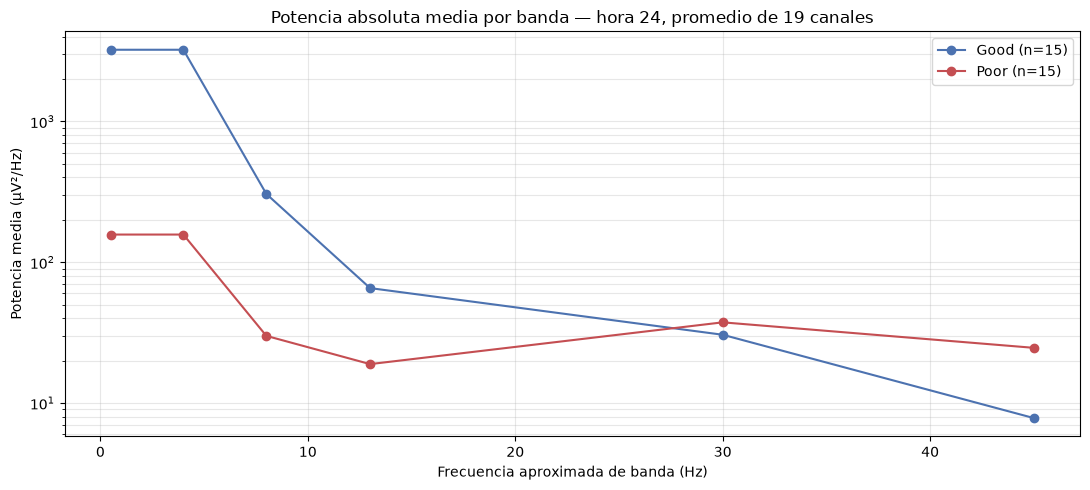

In [27]:
fig, ax = plt.subplots(figsize=(11, 5))
for grupo, color in [("Good", "#4C72B0"), ("Poor", "#C44E52")]:
    subset = eeg_features[eeg_features.Outcome == grupo]
    ax.semilogy(
        [0.5, 4, 8, 13, 30, 45],
        [subset["delta_abs"].mean(), subset["delta_abs"].mean(), subset["theta_abs"].mean(),
         subset["alpha_abs"].mean(), subset["beta_abs"].mean(), subset["gamma_abs"].mean()],
        marker="o", color=color, label=f"{grupo} (n={len(subset)})",
    )
ax.set_xlabel("Frecuencia aproximada de banda (Hz)")
ax.set_ylabel("Potencia media (µV²/Hz)")
ax.set_title("Potencia absoluta media por banda — hora 24, promedio de 19 canales")
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

### **Figura 2 · Mapas topográficos de potencia relativa (MNE)**

Se recuperan las señales preprocesadas de cada paciente de la muestra y se calcula, canal por canal, la potencia relativa promedio en las bandas alfa y delta dentro de cada grupo. `mne.viz.plot_topomap`, apoyado en las posiciones de electrodos del montaje `colin27_1020`, interpola esos 19 valores por canal sobre el cuero cabelludo.

In [28]:
def channelwise_relative_power(raw, band):
    psd = raw.compute_psd(method="welch", fmin=0.5, fmax=45.0, n_fft=1024, verbose=False)
    data, freqs = psd.get_data(return_freqs=True)
    data_uv2 = data * 1e12
    total = sum(band_power(data_uv2, freqs, lo, hi) for lo, hi in BANDS.values())
    lo, hi = BANDS[band]
    return band_power(data_uv2, freqs, lo, hi) / (total + 1e-20)


topo_alpha = {"Good": [], "Poor": []}
topo_delta = {"Good": [], "Poor": []}

for label in ("Good", "Poor"):
    for pid in eeg_features.loc[eeg_features.Outcome == label, "Patient"]:
        raw_p, _ = process_patient(pid)
        topo_alpha[label].append(channelwise_relative_power(raw_p, "alpha"))
        topo_delta[label].append(channelwise_relative_power(raw_p, "delta"))

topo_alpha = {k: np.mean(v, axis=0) for k, v in topo_alpha.items()}
topo_delta = {k: np.mean(v, axis=0) for k, v in topo_delta.items()}

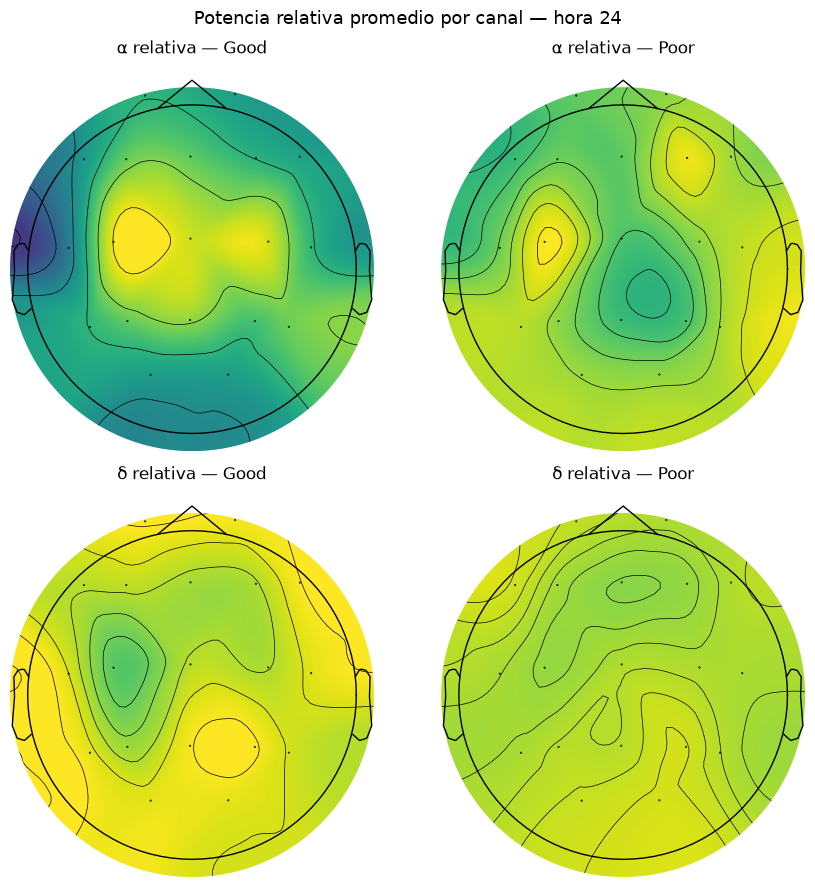

In [29]:
info_topo = mne.create_info(COMMON_CHANNELS, sfreq=TARGET_FS, ch_types="eeg")
info_topo.set_montage(MONTAGE, match_case=False)

fig, axes = plt.subplots(2, 2, figsize=(9, 9))

vmax_alpha = max(topo_alpha["Good"].max(), topo_alpha["Poor"].max())
vmax_delta = max(topo_delta["Good"].max(), topo_delta["Poor"].max())

for col, label in enumerate(["Good", "Poor"]):
    im, _ = mne.viz.plot_topomap(
        topo_alpha[label], info_topo, axes=axes[0, col], show=False,
        vlim=(0, vmax_alpha), cmap="viridis",
    )
    axes[0, col].set_title(f"α relativa — {label}")

    im2, _ = mne.viz.plot_topomap(
        topo_delta[label], info_topo, axes=axes[1, col], show=False,
        vlim=(0, vmax_delta), cmap="viridis",
    )
    axes[1, col].set_title(f"δ relativa — {label}")

fig.suptitle("Potencia relativa promedio por canal — hora 24", fontsize=13)
fig.tight_layout()
plt.show()

_El patrón espacial de ambas bandas es visualmente similar entre `Good` y `Poor` — coherente con la ausencia de diferencia estadísticamente significativa encontrada en 1.3: la distinción entre grupos, si existe en estos datos, no se concentra en una región del cuero cabelludo particular dentro de esta muestra._

### **Figura 3 · ADR y potencia relativa alfa por desenlace**

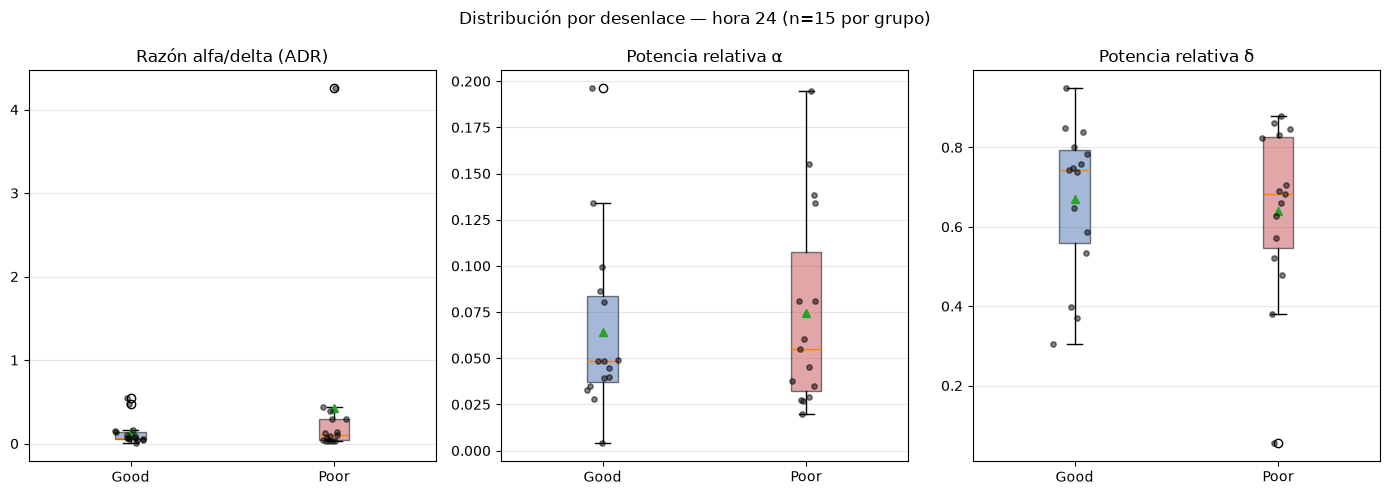

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, col, titulo in zip(
    axes,
    ["adr", "alpha_rel", "delta_rel"],
    ["Razón alfa/delta (ADR)", "Potencia relativa α", "Potencia relativa δ"],
):
    data_plot = [eeg_features.loc[eeg_features.Outcome == g, col].values for g in ["Good", "Poor"]]
    bp = ax.boxplot(data_plot, tick_labels=["Good", "Poor"], patch_artist=True, showmeans=True)
    for patch, color in zip(bp["boxes"], ["#4C72B0", "#C44E52"]):
        patch.set_facecolor(color)
        patch.set_alpha(0.5)
    for i, d in enumerate(data_plot, start=1):
        ax.scatter(np.random.normal(i, 0.04, size=len(d)), d, color="black", alpha=0.5, s=15, zorder=3)
    ax.set_title(titulo)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Distribución por desenlace — hora 24 (n=15 por grupo)")
plt.tight_layout()
plt.show()

## **3. Conclusiones**
---

### Cumplimiento de objetivos

| Objetivo (del proyecto, `README.md`) | Cómo lo aborda este notebook |
|---|---|
| Examinar la disponibilidad y estructura de registros EEG | Se reutiliza y verifica el inventario `RECORDS` / `.hea` de la Entrega 03 sobre 30 pacientes reales |
| Preparar una base analítica reproducible para las señales fisiológicas | Se define un pipeline determinista (semilla fija, criterios de elegibilidad explícitos) que produce `eeg_features_hour24.csv`, persistido para reproducibilidad |
| Analizar la relación entre variables clínicas y fisiológicas | Correlación, regresión logística/ordinal/lineal e inferencia formal entre 8 variables espectrales, `Age`, `CPC` y `Outcome` |
| Atender especialmente la información relevante para el pronóstico neurológico | Se usan específicamente variables con respaldo en la literatura de pronóstico post-paro (ADR, SEF95, asimetría) |

### Síntesis de resultados

1. **Es técnicamente viable** extraer, con datos reales de PhysioNet, un pipeline de adquisición-preprocesamiento-caracterización espectral íntegramente implementado con MNE-Python, y hacerlo de forma **25 veces más eficiente en transferencia de datos** que una descarga completa de los archivos `.mat`, gracias a peticiones HTTP `Range`.
2. **El único predictor con asociación estadísticamente sólida con el desenlace neurológico, en esta muestra, es `Age`** (ρ = −0.41, p = 0.023; OR = 0.93/año, p = 0.042), replicando lo ya encontrado en la rama clínica.
3. **Ninguna de las ocho variables espectrales EEG (potencias de banda, ADR, SEF95, asimetría) alcanza significancia estadística** frente al desenlace, ni en correlación, ni en regresión (univariable o multivariable), ni en las pruebas de hipótesis dedicadas — con tamaños de efecto pequeños (r biserial < 0.07 en valor absoluto).
4. El análisis de redundancia identificó que **5 de las 8 variables espectrales miden esencialmente la misma dimensión** (velocidad/continuidad del trazado), información que sería relevante para cualquier extensión futura del pipeline hacia modelos multivariables más grandes.

### Limitaciones

- **Tamaño de muestra.** n = 30 frente a los 2,421 registros elegibles identificados en la Entrega 03 (1.2 % de la muestra potencial). Los intervalos de confianza calculados son, en consecuencia, amplios, y la ausencia de significancia estadística no debe interpretarse como evidencia de ausencia de asociación real en la población.
- **Un único punto temporal.** Solo se usó la hora 24; la literatura de pronóstico EEG post-paro cardíaco sugiere que la información pronóstica a menudo se consolida o se hace más clara en ventanas posteriores (26-32 h) o al analizar la *evolución* del trazado entre horas, no una fotografía estática.
- **Ventana única de 90 s por paciente.** No se evalúa la variabilidad dentro del mismo registro (p. ej., reactividad a estímulos, presencia de brotes de supresión), que son las características que la literatura clínica reporta como más predictivas — más allá de la potencia espectral simple.
- **Posibles factores de confusión no controlados.** La sedación y el manejo dirigido de temperatura (`TTM`), activos en la mayoría de los pacientes a las 24 h, afectan directamente el trazado EEG independientemente del pronóstico subyacente, y no se ajustaron en los modelos.
- **Ajuste dentro de muestra, sin validación independiente.** El AUC de 0.764 del modelo logístico y el pseudo-R² de 0.164 se calcularon sobre los mismos 30 pacientes usados para ajustar el modelo; no hay separación entrenamiento/prueba ni validación cruzada, por lo que probablemente sobreestiman la capacidad predictiva real del modelo en pacientes nuevos.
- **Calidad de dato real, ya observada en producción.** Durante la ejecución se detectó y descartó automáticamente al menos un registro con las 19 señales en cero varianza durante toda la ventana (desconexión o pausa de adquisición) — un recordatorio de que, al escalar el pipeline, la validación de calidad de señal (más allá de la validación estructural ya hecha en la Entrega 03) debe ser una etapa explícita.

### Próximos pasos

Escalar el muestreo (más pacientes, más horas), incorporar características de continuidad/reactividad/supresión de brotes más allá de la potencia espectral estática, y validar cualquier modelo predictivo con un esquema de validación cruzada o un conjunto de prueba independiente antes de atribuirle capacidad pronóstica.

## **Créditos**
---

**Fuente de datos:** Amorim, E., Zheng, W., Lee, J. W., Herman, S., Ghassemi, M., Sivaraju, A., Gaspard, N., Hofmeijer, J., van Putten, M. J. A. M., Reyna, M., Clifford, G., & Westover, B. (2023). *I-CARE: International Cardiac Arrest REsearch consortium Database* (version 2.1). PhysioNet. https://doi.org/10.13026/m33r-bj81

**Herramienta de análisis de señal:** Gramfort, A., Luessi, M., Larson, E., Engemann, D. A., Strohmeier, D., Brodbeck, C., Goj, R., Jas, M., Brooks, T., Parkkonen, L., & Hämäläinen, M. (2013). *MEG and EEG data analysis with MNE-Python.* Frontiers in Neuroscience, 7, 267.

**Especificación de formato de señal:** Moody, G. B. *WFDB Applications Guide* — Signal File Format Specification (`SIGNAL(5)`). PhysioNet. https://physionet.org/physiotools/wag/signa-5.htm

**Estándar de filtrado clínico:** American Clinical Neurophysiology Society — parámetros técnicos recomendados para EEG clínico y monitorización prolongada, ya referenciados en `03_data_preparation.ipynb`.

**Continuidad metodológica:** este notebook construye directamente sobre el inventario e inspección de registros fisiológicos de `02_understanding_data.ipynb` y sobre el pipeline de selección/preprocesamiento validado en `03_data_preparation.ipynb`; complementa a `04_data_analysis.ipynb` (rama clínica de la Fase 4, sobre `clinical_prepared.csv`).